# NLP Workflow - Language Modeling Techniques

## This Notebook Covers
- Additional text cleaning to handle redacted texts in complaints
- Bag-of-words approach
- Sample LDA Modelling using bigrams and 5 topics
- Sentiment analysis using VADER: polarity scoring across complaint records
- Feature engineering from text: sentiment scores, complaint length, keyword flags
- Exploratory analysis of sentiment distributions across customer segments
- VADER vs Transformers for various sample sizes of data

## Libraries Used
- **Python:** pandas, nltk, re, numpy, sklearn, VADER (vaderSentiment)
- **Transformers:** finBERT, RoBERT-a
- **PyTorch:** torch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re
import string
from tqdm import tqdm
import time

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("data/text_processed_complaints.csv",engine="python",
    on_bad_lines="skip")
df.head()

,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,word_count
0,0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,119
1,1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,68
2,2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,140
3,3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,18
4,4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,17


In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,68


### NLP - Bag-of-Words (TF-IDF) Approach

In [7]:
def extract_bow_features(df, max_features=100):
    """
    Extract Bag-of-Words features using TF-IDF
    - Uses unigrams + bigrams (n-gram range 1-2)
    - TF-IDF weighting for importance
    - Smoothing to handle unseen terms
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with 'narrative_no_stopwords' column
    max_features : int
        Maximum number of features to keep
        
    Returns:
    --------
    X_tfidf : sparse matrix
        TF-IDF feature matrix
    tfidf_vectorizer : TfidfVectorizer
        Fitted vectorizer
    feature_names : array
        Feature names
    """
    
    print("=" * 70)
    print("BAG-OF-WORDS (TF-IDF) FEATURE EXTRACTION")
    print("=" * 70)
    
    # Filter to complaints with text
    df_text = df[df['narrative_no_stopwords'].notna()].copy()
    
    print(f"\nDataset: {len(df_text):,} complaints with text")
    
    # ─── TF-IDF Vectorizer ───
    print("\nCreating TF-IDF vectors with bigrams...")
    
    tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),          # Unigrams + bigrams
        min_df=5,                    # Ignore terms in <5 documents
        max_df=0.7,                  # Ignore terms in >70% documents
        sublinear_tf=True,           # Use log scaling for term frequency
        smooth_idf=True,             # Add smoothing (Laplace smoothing)
        norm='l2'                    # L2 normalization
    )
    
    X_tfidf = tfidf_vectorizer.fit_transform(df_text['narrative_no_stopwords'])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print(f"  Created TF-IDF matrix: {X_tfidf.shape}")
    print(f"     Documents: {X_tfidf.shape[0]:,}")
    print(f"     Features (terms): {X_tfidf.shape[1]}")
    
    # ─── Feature Statistics ───
    print(f"\nTop 20 most important terms (by avg TF-IDF):")
    
    # Calculate average TF-IDF score per term
    avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
    term_importance = sorted(zip(feature_names, avg_tfidf), 
                            key=lambda x: x[1], reverse=True)
    
    for i, (term, score) in enumerate(term_importance[:20], 1):
        print(f"  {i:2d}. {term:25s}: {score:.4f}")
    
    # Identify bigrams vs unigrams
    bigrams = [term for term in feature_names if ' ' in term]
    unigrams = [term for term in feature_names if ' ' not in term]
    
    print(f"\nTerm breakdown:")
    print(f"   Unigrams: {len(unigrams)}")
    print(f"   Bigrams:  {len(bigrams)}")
    
    print(f"\nSample bigrams (most important):")
    bigram_scores = [(term, avg_tfidf[list(feature_names).index(term)]) 
                     for term in bigrams]
    bigram_scores.sort(key=lambda x: x[1], reverse=True)
    
    for i, (bigram, score) in enumerate(bigram_scores[:10], 1):
        print(f"  {i:2d}. {bigram:30s}: {score:.4f}")
    
    return X_tfidf, tfidf_vectorizer, feature_names, df_text

In [8]:
X_tfidf, tfidf_vectorizer, feature_names, df_with_bow = extract_bow_features(
    df, 
    max_features=100
)

BAG-OF-WORDS (TF-IDF) FEATURE EXTRACTION

Dataset: 1,400,010 complaints with text

Creating TF-IDF vectors with bigrams...
  Created TF-IDF matrix: (1400010, 100)
     Documents: 1,400,010
     Features (terms): 100

Top 20 most important terms (by avg TF-IDF):
   1. xxxx                     : 0.1752
   2. xxxx xxxx                : 0.1393
   3. report                   : 0.1011
   4. not                      : 0.0976
   5. information              : 0.0850
   6. account                  : 0.0847
   7. credit report            : 0.0822
   8. xx                       : 0.0791
   9. accounts                 : 0.0766
  10. reporting                : 0.0752
  11. consumer                 : 0.0644
  12. 15                       : 0.0553
  13. xx xx                    : 0.0549
  14. no                       : 0.0521
  15. amount                   : 0.0519
  16. inaccurate               : 0.0514
  17. please                   : 0.0503
  18. act                      : 0.0421
  19. debt        

In [9]:
def extract_bow_features_cleaned(df, max_features=100):
    """
    Extract Bag-of-Words features using TF-IDF
    WITH filtering of CFPB redacted terms
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with 'narrative_no_stopwords' column
    max_features : int
        Maximum number of features to keep
        
    Returns:
    --------
    X_tfidf : sparse matrix
        TF-IDF feature matrix
    tfidf_vectorizer : TfidfVectorizer
        Fitted vectorizer
    feature_names : array
        Feature names (terms)
    """
    
    print("=" * 70)
    print("BAG-OF-WORDS (TF-IDF) FEATURE EXTRACTION - CLEANED")
    print("=" * 70)
    
    # Filter to complaints with text
    df_text = df[df['narrative_no_stopwords'].notna()].copy()
    
    print(f"\nDataset: {len(df_text):,} complaints with text")
    
    # ─── Remove redacted terms from text ───
    print("\nCleaning redacted CFPB terms (XXXX, XX, etc.)...")
    
    def clean_redacted_terms(text):
        """Remove CFPB redaction markers"""
        if not text or pd.isna(text):
            return ""
    
        # Remove patterns like: xxxx, xx, xxx, xxxx xxxx, etc.
        # Match 2+ consecutive x's (case insensitive)
        text = re.sub(r'\b[xX]{2,}\b', '', text)
        
        # Clean up extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    df_text['narrative_cleaned'] = df_text['narrative_no_stopwords'].apply(clean_redacted_terms)
    
    # Checking removed quantity
    avg_len_before = df_text['narrative_no_stopwords'].str.len().mean()
    avg_len_after = df_text['narrative_cleaned'].str.len().mean()
    reduction_pct = (avg_len_before - avg_len_after) / avg_len_before * 100
    
    print(f"   Avg text length before: {avg_len_before:.0f} chars")
    print(f"   Avg text length after:  {avg_len_after:.0f} chars")
    print(f"   Reduction: {reduction_pct:.1f}%")
    
    # ─── TF-IDF Vectorizer with additional filtering ───
    print("\nCreating TF-IDF vectors with bigrams...")
    
    # Custom token pattern to exclude remaining redacted patterns
    token_pattern = r'(?u)\b[a-zA-Z][a-zA-Z]+\b'  # At least 2 letters, no numbers-only
    
    tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),          # Unigrams + bigrams
        min_df=10,                   # Must appear in at least 10 documents
        max_df=0.7,                  # Ignore terms in >70% of documents
        sublinear_tf=True,           # Use log scaling
        smooth_idf=True,             # Laplace smoothing
        norm='l2',                   # L2 normalization
        token_pattern=token_pattern, # Only alphabetic tokens (2+ letters)
        lowercase=True
    )
    
    X_tfidf = tfidf_vectorizer.fit_transform(df_text['narrative_cleaned'])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    print(f"  Created TF-IDF matrix: {X_tfidf.shape}")
    print(f"     Documents: {X_tfidf.shape[0]:,}")
    print(f"     Features (terms): {X_tfidf.shape[1]}")
    
    # ─── Verify no redacted terms remain ───
    print(f"\nVerifying no redacted terms in features...")
    
    redacted_found = [term for term in feature_names if 'xx' in term.lower()]
    
    if redacted_found:
        print(f"   Warning: Found {len(redacted_found)} potential redacted terms:")
        for term in redacted_found[:5]:
            print(f"      - {term}")
    else:
        print(f"   No redacted terms found!")
    
    # ─── Feature Statistics ───
    print(f"\nTop 20 most important terms (by avg TF-IDF):")
    
    avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
    term_importance = sorted(zip(feature_names, avg_tfidf), 
                            key=lambda x: x[1], reverse=True)
    
    for i, (term, score) in enumerate(term_importance[:20], 1):
        print(f"  {i:2d}. {term:30s}: {score:.4f}")
    
    # Identify bigrams vs unigrams
    bigrams = [term for term in feature_names if ' ' in term]
    unigrams = [term for term in feature_names if ' ' not in term]
    
    print(f"\nTerm breakdown:")
    print(f"   Unigrams: {len(unigrams)}")
    print(f"   Bigrams:  {len(bigrams)}")
    
    print(f"\nTop 10 bigrams (most important):")
    bigram_scores = [(term, avg_tfidf[list(feature_names).index(term)]) 
                     for term in bigrams]
    bigram_scores.sort(key=lambda x: x[1], reverse=True)
    
    for i, (bigram, score) in enumerate(bigram_scores[:10], 1):
        print(f"  {i:2d}. '{bigram:35s}': {score:.4f}")
    
    return X_tfidf, tfidf_vectorizer, feature_names, df_text

In [10]:
# ─── USAGE ───
X_tfidf_cleaned, tfidf_vectorizer_cleaned, feature_names_cleaned, df_with_bow_cleaned = extract_bow_features_cleaned(
    df, 
    max_features=100
)

BAG-OF-WORDS (TF-IDF) FEATURE EXTRACTION - CLEANED

Dataset: 1,400,010 complaints with text

Cleaning redacted CFPB terms (XXXX, XX, etc.)...
   Avg text length before: 732 chars
   Avg text length after:  651 chars
   Reduction: 11.1%

Creating TF-IDF vectors with bigrams...
  Created TF-IDF matrix: (1400010, 100)
     Documents: 1,400,010
     Features (terms): 100

Verifying no redacted terms in features...
   No redacted terms found!

Top 20 most important terms (by avg TF-IDF):
   1. report                        : 0.1055
   2. not                           : 0.1045
   3. account                       : 0.0922
   4. information                   : 0.0900
   5. credit report                 : 0.0861
   6. accounts                      : 0.0796
   7. reporting                     : 0.0793
   8. consumer                      : 0.0672
   9. amount                        : 0.0609
  10. no                            : 0.0566
  11. please                        : 0.0527
  12. inaccurate 

In [11]:
print("\nSaving TF-IDF features...")
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer_cleaned, f)

print("Saved: tfidf_vectorizer.pkl")


Saving TF-IDF features...
Saved: tfidf_vectorizer.pkl


### NLP - Topic Modeling with LDA

In [12]:
def extract_topics_lda(df, n_topics=5, n_top_words=10):
    """
    Extract topics using Latent Dirichlet Allocation
    
    Helps identify what people complain about
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with complaints
    n_topics : int
        Number of topics to extract
    n_top_words : int
        Number of top words per topic to display
    """
    
    print("=" * 70)
    print("TOPIC MODELING (LDA)")
    print("=" * 70)
    
    print(f"\nExtracting {n_topics} topics from complaints...")
    
    # Using Count Vectorizer
    count_vectorizer = CountVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=10,
        max_df=0.7,
        stop_words='english'
    )
    
    df_text = df[df['narrative_no_stopwords'].notna()]
    X_counts = count_vectorizer.fit_transform(df_text['narrative_no_stopwords'])
    
    # Train LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=20,
        random_state=42,
        n_jobs=-1
    )
    
    lda.fit(X_counts)
    
    print(f"  LDA training complete!")
    
    # Display topics
    print(f"\nDiscovered Topics:\n")
    
    feature_names = count_vectorizer.get_feature_names_out()
    
    topic_names = []
    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"Topic {topic_idx + 1}:")
        print(f"  {', '.join(top_words)}")
        print()
        
        # Creating human-readable topic name
        topic_name = f"Topic_{topic_idx+1}: {top_words[0]}/{top_words[1]}"
        topic_names.append(topic_name)
    
    # Assigning dominant topic to each complaint
    doc_topics = lda.transform(X_counts)
    dominant_topics = doc_topics.argmax(axis=1)
    
    print(f"\nTopic distribution across complaints:")
    topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
    
    for topic_idx, count in topic_counts.items():
        pct = count / len(dominant_topics) * 100
        print(f"  Topic {topic_idx + 1}: {count:7,} ({pct:5.1f}%)")
    
    return lda, count_vectorizer, dominant_topics

In [13]:
# ─── USAGE ───
lda_model, count_vec, topics = extract_topics_lda(df, n_topics=5)

TOPIC MODELING (LDA)

Extracting 5 topics from complaints...
  LDA training complete!

Discovered Topics:

Topic 1:
  consumer, 15, section, reporting, information, agency, consumer reporting, 1681, reporting agency, states

Topic 2:
  xxxx, xx, account, xx xx, xx xxxx, payment, bank, card, received, loan

Topic 3:
  report, reporting, information, credit report, accounts, inaccurate, account, 15, fcra, credit reporting

Topic 4:
  debt, identity, report, consumer, information, theft, identity theft, fraudulent, accounts, complaint

Topic 5:
  xxxx, xxxx xxxx, xx, xx xx, xx xxxx, xxxxxxxx, xxxxxxxx xxxx, balance, xxxx xxxxxxxx, date


Topic distribution across complaints:
  Topic 1: 122,962 (  8.8%)
  Topic 2: 330,601 ( 23.6%)
  Topic 3: 496,786 ( 35.5%)
  Topic 4: 216,645 ( 15.5%)
  Topic 5: 233,016 ( 16.6%)


In [15]:
def extract_topics_lda_cleaned(df, n_topics=5, n_top_words=10):
    """
    Extract topics using LDA with aggressive redaction filtering
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with complaints
    n_topics : int
        Number of topics to extract
    n_top_words : int
        Number of top words per topic to display
    """
    
    print("=" * 70)
    print("TOPIC MODELING (LDA) CLEANED")
    print("=" * 70)
    
    print(f"\nExtracting {n_topics} topics from complaints...")
    
    # Getting texts and clean redactions
    df_text = df[df['narrative_clean'].notna()].copy()
    
    print(f"   Processing {len(df_text):,} complaints")
    
    # Cleaning redactions
    def clean_for_lda(text):
        if not text or pd.isna(text):
            return ""
        
        # Remove all patterns with X's (case insensitive)
        text = re.sub(r'\b[xX]+\b', '', text)
        text = re.sub(r'\b[xX]{2,}', '', text)
        
        # Remove standalone numbers (often redacted dates/amounts)
        text = re.sub(r'\b\d+\b', '', text)
        
        # Remove very short tokens
        text = re.sub(r'\b\w{1,2}\b', '', text)
        
        # Clean whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    # Use tqdm for cleaning progress
    tqdm.pandas(desc="Cleaning text")
    df_text['narrative_for_lda'] = df_text['narrative_clean'].progress_apply(clean_for_lda)
    
    # Filter out empty texts after cleaning
    df_text = df_text[df_text['narrative_for_lda'].str.len() > 10]
    
    print(f"   After cleaning: {len(df_text):,} complaints")
    
    # Count Vectorizer with strict filtering
    count_vectorizer = CountVectorizer(
        max_features=1000,
        ngram_range=(1, 2),        # Unigrams + bigrams
        min_df=20,                 # Must appear in 20+ docs
        max_df=0.6,                # Ignore terms in >60% of docs
        token_pattern=r'\b[a-zA-Z]{3,}\b',  # Only words with 3+ letters
        stop_words='english'
    )
    
    X_counts = count_vectorizer.fit_transform(df_text['narrative_for_lda'])
    
    print(f"   Vocabulary size: {X_counts.shape[1]:,} terms")
    
    # Verify no redacted terms in vocabulary
    vocab = count_vectorizer.get_feature_names_out()
    redacted_in_vocab = [term for term in vocab if 'x' in term.lower() and term.lower().count('x') >= 2]
    
    if redacted_in_vocab:
        print(f"   Warning: {len(redacted_in_vocab)} potential redacted terms still present")
        print(f"     Examples: {redacted_in_vocab[:5]}")
    else:
        print(f"   No redacted terms in vocabulary!")
    
    # Train LDA
    print(f"\nTraining LDA model...")
    
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=30,               
        learning_method='batch',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    lda.fit(X_counts)
    elapsed = time.time() - start_time

    print(f"   LDA training complete ({elapsed:.1f} seconds)")
    
    # Display topics with interpretation
    print(f"\nDiscovered Topics:\n")
    
    feature_names = count_vectorizer.get_feature_names_out()
    
    topic_names = []
    topic_interpretations = []
    
    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"Topic {topic_idx + 1}:")
        print(f"  Keywords: {', '.join(top_words)}")
        
        # Try to interpret topic
        interpretation = interpret_topic(top_words)
        topic_interpretations.append(interpretation)
        print(f"  Interpretation: {interpretation}")
        print()
        
        # Create human-readable topic name
        topic_name = f"Topic_{topic_idx+1}: {interpretation}"
        topic_names.append(topic_name)
    
    # Assign dominant topic to each complaint
    doc_topics = lda.transform(X_counts)
    dominant_topics = doc_topics.argmax(axis=1)
    
    print(f"\nTopic distribution across complaints:")
    topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
    
    for topic_idx, count in topic_counts.items():
        pct = count / len(dominant_topics) * 100
        interpretation = topic_interpretations[topic_idx]
        print(f"  Topic {topic_idx + 1} ({interpretation}): {count:7,} ({pct:5.1f}%)")
    
    # Add topic assignments to dataframe
    df_text['dominant_topic'] = dominant_topics
    df_text['topic_name'] = [topic_interpretations[t] for t in dominant_topics]
    
    return lda, count_vectorizer, dominant_topics, topic_interpretations, df_text

In [16]:
def interpret_topic(top_words):
    """
    Heuristic interpretation of LDA topics based on keywords
    """
    
    keywords_str = ' '.join(top_words).lower()
    
    # Identity theft / Fraud
    if 'identity' in keywords_str or 'theft' in keywords_str or 'fraud' in keywords_str:
        return "Identity Theft / Fraud"
    
    # Credit reporting
    elif 'credit report' in keywords_str or 'reporting' in keywords_str:
        return "Credit Reporting Errors"
    
    # Debt collection
    elif 'debt' in keywords_str or 'collection' in keywords_str:
        return "Debt Collection"
    
    # Account issues
    elif 'account' in keywords_str or 'payment' in keywords_str:
        return "Account / Payment Issues"
    
    # Legal / FCRA
    elif 'fcra' in keywords_str or 'section' in keywords_str or 'agency' in keywords_str:
        return "Legal / FCRA Violations"
    
    # Billing disputes
    elif 'charge' in keywords_str or 'fee' in keywords_str or 'billing' in keywords_str:
        return "Billing Disputes"
    
    else:
        return "General Complaints"

In [22]:
# ─── USAGE ───
lda_model, count_vec, topics, topic_names, df_with_topics = extract_topics_lda_cleaned(
    df, 
    n_topics=5
)

TOPIC MODELING (LDA) CLEANED

Extracting 5 topics from complaints...
   Processing 1,400,010 complaints


Cleaning text: 100%|███████████████████████████████████████| 1400010/1400010 [01:30<00:00, 15458.48it/s]


   After cleaning: 1,399,625 complaints
   Vocabulary size: 1,000 terms
   No redacted terms in vocabulary!

Training LDA model...
iteration: 1 of max_iter: 30
iteration: 2 of max_iter: 30
iteration: 3 of max_iter: 30
iteration: 4 of max_iter: 30
iteration: 5 of max_iter: 30
iteration: 6 of max_iter: 30
iteration: 7 of max_iter: 30
iteration: 8 of max_iter: 30
iteration: 9 of max_iter: 30
iteration: 10 of max_iter: 30
iteration: 11 of max_iter: 30
iteration: 12 of max_iter: 30
iteration: 13 of max_iter: 30
iteration: 14 of max_iter: 30
iteration: 15 of max_iter: 30
iteration: 16 of max_iter: 30
iteration: 17 of max_iter: 30
iteration: 18 of max_iter: 30
iteration: 19 of max_iter: 30
iteration: 20 of max_iter: 30
iteration: 21 of max_iter: 30
iteration: 22 of max_iter: 30
iteration: 23 of max_iter: 30
iteration: 24 of max_iter: 30
iteration: 25 of max_iter: 30
iteration: 26 of max_iter: 30
iteration: 27 of max_iter: 30
iteration: 28 of max_iter: 30
iteration: 29 of max_iter: 30
iteratio

### NLP - VADER Approach

In [24]:
# Check if 'complaint' is driving the score
print("Checking 'complaint' word frequency...")

# Count how many complaints contain the word "complaint"
contains_complaint = df['narrative_clean'].str.contains('complaint', case=False, na=False)
print(f"Complaints with word 'complaint': {contains_complaint.sum():,} ({contains_complaint.mean()*100:.1f}%)")

# Check for other common urgency words
for word in ['report', 'complaint', 'legal', 'immediately']:
    count = df['narrative_clean'].str.contains(word, case=False, na=False).sum()
    pct = count / len(df) * 100
    print(f"Contains '{word}': {count:,} ({pct:.1f}%)")

Checking 'complaint' word frequency...
Complaints with word 'complaint': 273,852 (19.6%)
Contains 'report': 1,043,438 (74.5%)
Contains 'complaint': 273,852 (19.6%)
Contains 'legal': 221,945 (15.9%)
Contains 'immediately': 167,397 (12.0%)


In [25]:
df.head(4)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,68
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,140
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,18


In [26]:
class NLPFeatureExtractor:
    """
    Extract comprehensive NLP features from complaint narratives
    """
    
    def __init__(self):
        self.vader = SentimentIntensityAnalyzer()
        
        # Urgency keywords
        self.urgency_words = {
            'urgent', 'immediately', 'asap', 'emergency', 'critical',
            'lawyer', 'attorney', 'sue', 'legal', 'court', 'report',
            'bbb', 'ftc', 'cfpb', 'complaint', 'authority'
        }
        
        # Churn indicator keywords
        self.churn_words = {
            'close', 'closing', 'cancel', 'canceling', 'terminate',
            'switch', 'switching', 'leave', 'leaving', 'done'
        }
        
        # Loyalty keywords
        self.loyalty_words = {
            'year', 'years', 'decade', 'decades', 'loyal', 'longtime',
            'long-time', 'customer', 'member'
        }
    
    def extract_sentiment(self, text):
        """
        Extract sentiment using VADER
        
        Returns:
        --------
        dict with keys: compound, neg, neu, pos
        """
        if not text or pd.isna(text):
            return {'compound': 0, 'neg': 0, 'neu': 1, 'pos': 0}
        
        scores = self.vader.polarity_scores(text)
        return scores
    
    def detect_urgency(self, text):
        """Detect urgency level with weighted scoring"""
        if not text:
            return 0
        
        text_lower = text.lower()
        
        # Urgency keywords (removed 'report' and 'complaint')
        urgency_weights = {
            # Legal/regulatory threats (HIGH urgency)
            'lawyer': 1.0,
            'attorney': 1.0,
            'sue': 1.0,
            'lawsuit': 1.0,
            'court': 0.9,
            'cfpb': 0.9,
            'ftc': 0.9,
            'bbb': 0.8,
            'regulatory': 0.8,
            'legal action': 1.0,
            
            # Time-sensitive language
            'urgent': 0.8,
            'immediately': 0.8,
            'asap': 0.7,
            'emergency': 0.9,
            'critical': 0.7,
            'right now': 0.7,
            
            # Escalation indicators
            'unacceptable': 0.6,
            'escalate': 0.7,
            'fraud': 0.8,
            'scam': 0.8,
        }
        
        urgency_score = 0
        for word, weight in urgency_weights.items():
            if word in text_lower:
                urgency_score += weight
        
        return min(urgency_score, 1.0)
    
    def detect_churn_intent(self, text):
        """Detect intent to close account"""
        if not text:
            return 0
        
        text_lower = text.lower()
        
        churn_patterns = {
            'closing my account': 1.0, 'close my account': 1.0,
            'closed my account': 1.0, 'cancel my account': 1.0,
            'canceling my': 0.9, 'terminate': 0.8,
            'switching to': 0.8, 'switch to': 0.8,
            'leaving': 0.7, 'done with': 0.9, "i'm done": 0.8,
            'close': 0.4, 'cancel': 0.4, 'switch': 0.3, 'leave': 0.3,
        }
        
        max_score = 0
        for pattern, weight in sorted(churn_patterns.items(), key=lambda x: -len(x[0])):
            if pattern in text_lower:
                max_score = max(max_score, weight)
        
        return max_score
    
    def detect_loyalty_mentions(self, text):
        """Detect mentions of long-term customer relationship"""
        if not text:
            return 0
        
        text_lower = text.lower()
        
        # Check for specific patterns
        loyalty_score = 0
        
        # Pattern: "X years"
        years_match = re.findall(r'(\d+)\s*years?', text_lower)
        if years_match:
            loyalty_score = min(max([int(y) for y in years_match]) / 20, 1.0)
        
        # Pattern: loyalty keywords
        loyalty_count = sum(1 for word in self.loyalty_words if word in text_lower)
        loyalty_score += min(loyalty_count * 0.2, 0.5)
        
        return min(loyalty_score, 1.0)
    
    def extract_all_features(self, text):
        """Extract all NLP features"""
        
        sentiment = self.extract_sentiment(text)
        
        features = {
            'sentiment_compound': sentiment['compound'],
            'sentiment_neg': sentiment['neg'],
            'sentiment_neu': sentiment['neu'],
            'sentiment_pos': sentiment['pos'],
            'urgency_score': self.detect_urgency(text),
            'churn_intent': self.detect_churn_intent(text),
            'loyalty_score': self.detect_loyalty_mentions(text),
            'text_length': len(text) if text else 0,
            'word_count': len(text.split()) if text else 0
        }
        
        return features

In [38]:
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,word_count,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,119,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,68,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,140,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,18,0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,17,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107


In [39]:
feature_cols_to_drop = [
    'sentiment_compound', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
    'urgency_score', 'churn_intent', 'loyalty_score', 'text_length', 'word_count'
]

existing_features = [col for col in feature_cols_to_drop if col in df.columns]

if existing_features:
    print(f"Found existing features: {existing_features}")
    print(f"  Dropping them to force fresh extraction...")
    df = df.drop(columns=existing_features)
    print(f"   Dropped {len(existing_features)} old feature columns")
else:
    print(f"   No existing features found - proceeding with fresh extraction")

print(f"\nCurrent dataframe shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

Found existing features: ['sentiment_compound', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'urgency_score', 'churn_intent', 'loyalty_score', 'text_length', 'word_count']
  Dropping them to force fresh extraction...
   Dropped 9 old feature columns

Current dataframe shape: (1400010, 20)
   Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID', 'narrative_clean', 'narrative_no_stopwords']


In [40]:
def extract_nlp_features(df):
    """
    Extract NLP features for all complaints (processing only, no viz)
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Preprocessed CFPB complaints
        
    Returns:
    --------
    df : pandas.DataFrame
        Dataframe with NLP feature columns added
    """
    
    print("=" * 70)
    print("NLP FEATURE EXTRACTION")
    print("=" * 70)
    
    extractor = NLPFeatureExtractor()
    
    print("\nExtracting features from narratives...")
    print(f"   Total complaints to process: {len(df):,}")
    
    # Extract features for each complaint
    features_list = []
    
    for idx, row in df.iterrows():
        if idx % 100000 == 0 and idx > 0:
            print(f"  Progress: {idx:,} / {len(df):,} ({idx/len(df)*100:.1f}%)")
        
        text = row['narrative_clean']
        features = extractor.extract_all_features(text)
        features_list.append(features)
    
    print(f"  Progress: {len(df):,} / {len(df):,} (100.0%)")
    
    # Convert to dataframe and merge
    features_df = pd.DataFrame(features_list)
    df = pd.concat([df, features_df], axis=1)
    
    print(f"\nFeature extraction complete!")
    print(f"   Processed: {len(df):,} complaints")
    print(f"   New columns added: {list(features_df.columns)}")
    
    return df

In [41]:
# ─── USAGE ───
df = extract_nlp_features(df)

NLP FEATURE EXTRACTION

Extracting features from narratives...
   Total complaints to process: 1,400,010
  Progress: 100,000 / 1,400,010 (7.1%)
  Progress: 200,000 / 1,400,010 (14.3%)
  Progress: 300,000 / 1,400,010 (21.4%)
  Progress: 400,000 / 1,400,010 (28.6%)
  Progress: 500,000 / 1,400,010 (35.7%)
  Progress: 600,000 / 1,400,010 (42.9%)
  Progress: 700,000 / 1,400,010 (50.0%)
  Progress: 800,000 / 1,400,010 (57.1%)
  Progress: 900,000 / 1,400,010 (64.3%)
  Progress: 1,000,000 / 1,400,010 (71.4%)
  Progress: 1,100,000 / 1,400,010 (78.6%)
  Progress: 1,200,000 / 1,400,010 (85.7%)
  Progress: 1,300,000 / 1,400,010 (92.9%)
  Progress: 1,400,000 / 1,400,010 (100.0%)
  Progress: 1,400,010 / 1,400,010 (100.0%)

Feature extraction complete!
   Processed: 1,400,010 complaints
   New columns added: ['sentiment_compound', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'urgency_score', 'churn_intent', 'loyalty_score', 'text_length', 'word_count']


In [42]:
print(df.shape)
df.head(5)

(1400010, 29)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17


In [43]:
print(f"\nDuplicate columns: {df.columns[df.columns.duplicated()].tolist()}")


Duplicate columns: []


In [44]:
df = df.loc[:, ~df.columns.duplicated()]
print(df.shape)
df.head(5)

(1400010, 29)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17


In [45]:
# Basic statistics
print("\nQuick statistics:")
    
feature_cols = [
    'sentiment_compound', 'sentiment_neg', 'urgency_score',
    'churn_intent', 'loyalty_score'
]
    
for col in feature_cols:
    col_min = float(df[col].min())
    col_mean = float(df[col].mean())
    col_max = float(df[col].max())
    print(f"   {col:25s}: min={col_min:.3f}, mean={col_mean:.3f}, max={col_max:.3f}")


Quick statistics:
   sentiment_compound       : min=-1.000, mean=-0.050, max=1.000
   sentiment_neg            : min=0.000, mean=0.090, max=1.000
   urgency_score            : min=0.000, mean=0.469, max=1.000
   churn_intent             : min=0.000, mean=0.078, max=1.000
   loyalty_score            : min=0.000, mean=0.070, max=1.000


VISUALIZING NLP FEATURES

Feature statistics:
       sentiment_compound  sentiment_neg  urgency_score  churn_intent  loyalty_score
count        1.400010e+06   1.400010e+06   1.400010e+06  1.400010e+06   1.400010e+06
mean        -5.002125e-02   9.043320e-02   4.690918e-01  7.802337e-02   7.001064e-02
std          6.860562e-01   6.255253e-02   4.665947e-01  1.935235e-01   1.576957e-01
min         -1.000000e+00   0.000000e+00   0.000000e+00  0.000000e+00   0.000000e+00
25%         -7.355000e-01   4.600000e-02   0.000000e+00  0.000000e+00   0.000000e+00
50%         -5.980000e-02   8.000000e-02   7.000000e-01  0.000000e+00   0.000000e+00
75%          6.177000e-01   1.260000e-01   1.000000e+00  0.000000e+00   0.000000e+00
max          1.000000e+00   1.000000e+00   1.000000e+00  1.000000e+00   1.000000e+00

Generating distribution plots...
Saved: nlp_features_distribution.png


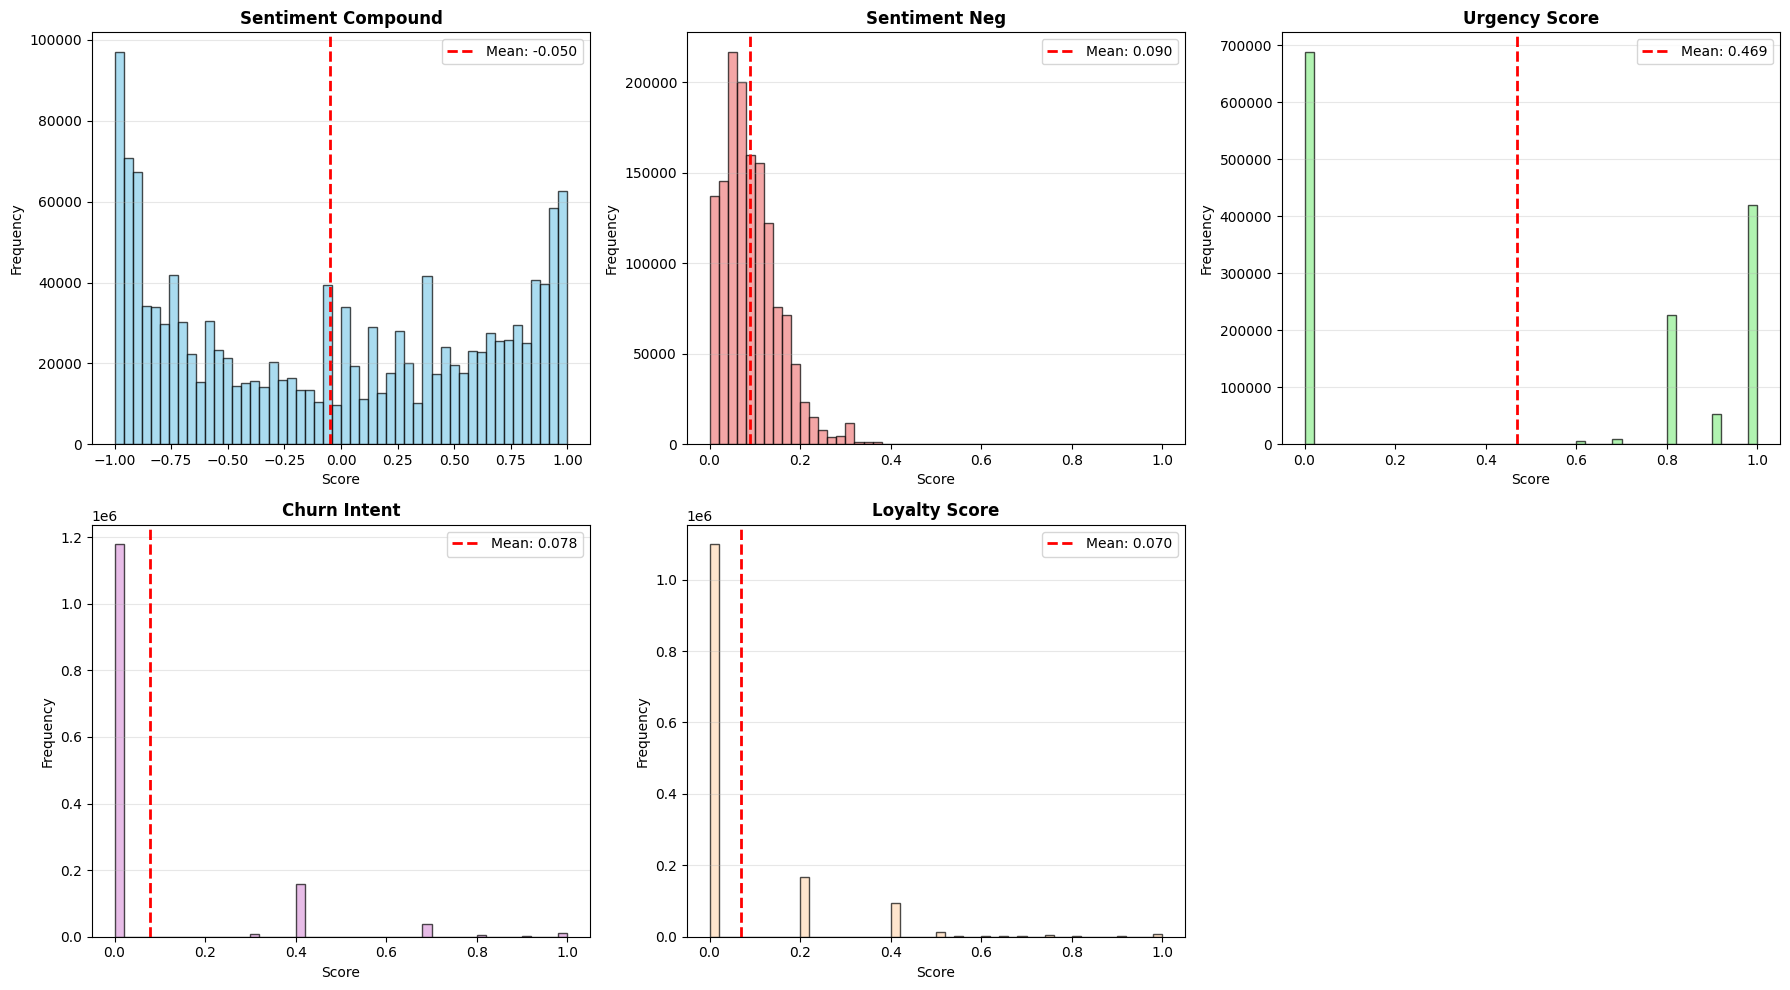


Discrete score distribution:

  Urgency Score - Top 10 values:
    0.00: 688,271 ( 49.2%)
    0.60:   5,176 (  0.4%)
    0.70:   8,286 (  0.6%)
    0.80: 225,933 ( 16.1%)
    0.90:  52,630 (  3.8%)
    1.00: 419,714 ( 30.0%)

  Churn Intent - Top 10 values:
    0.00: 1,178,226 ( 84.2%)
    0.30:   8,354 (  0.6%)
    0.40: 157,333 ( 11.2%)
    0.70:  36,858 (  2.6%)
    0.80:   4,844 (  0.3%)
    0.90:   2,767 (  0.2%)
    1.00:  11,628 (  0.8%)

Feature correlations:

Saved: nlp_features_correlation.png


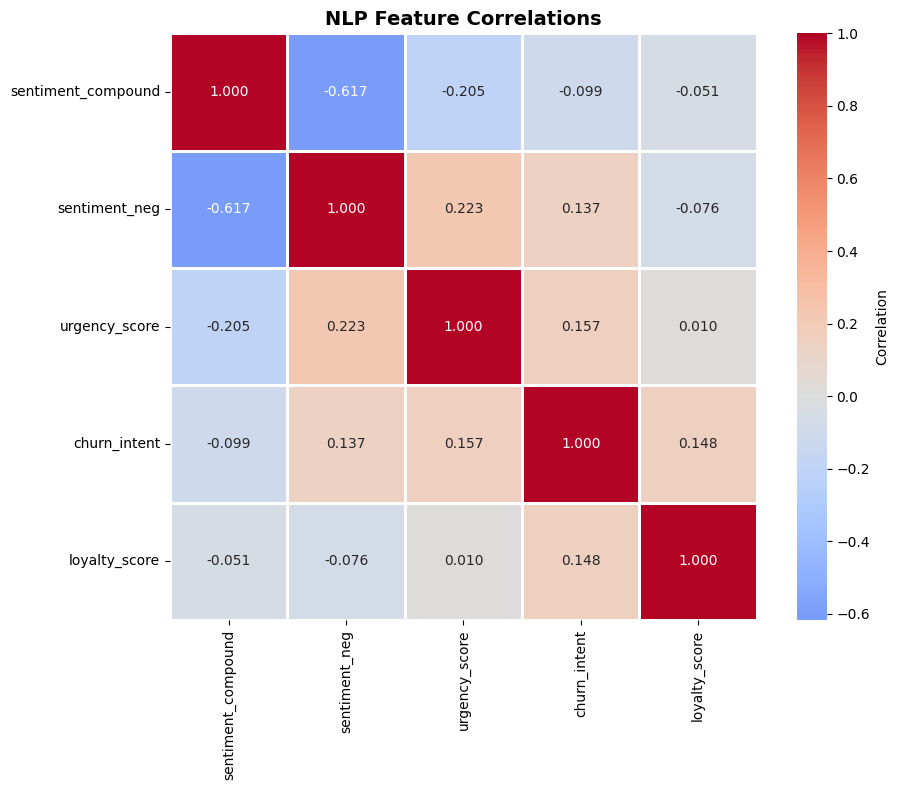


VISUALIZATION COMPLETE


In [46]:
def visualize_nlp_features(df):
    """
    Visualize NLP feature distributions
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with extracted NLP features
    """
    
    print("=" * 70)
    print("VISUALIZING NLP FEATURES")
    print("=" * 70)
    
    feature_cols = [
        'sentiment_compound', 'sentiment_neg', 'urgency_score',
        'churn_intent', 'loyalty_score'
    ]
    
    # Check if features exist
    missing_cols = [col for col in feature_cols if col not in df.columns]
    if missing_cols:
        print(f"ERROR: Missing columns: {missing_cols}")
        print("Run extract_nlp_features() first!")
        return
    
    # ─── Detailed Statistics ───
    print("\nFeature statistics:")
    stats = df[feature_cols].describe()
    print(stats.to_string())
    
    # ─── Distribution Plots ───
    print("\nGenerating distribution plots...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'plum', 'peachpuff']
    
    for i, col in enumerate(feature_cols):
        # Get data and remove NaNs
        data = df[col].dropna().values
        
        # Create histogram
        axes[i].hist(data, bins=50, color=colors[i], 
                     edgecolor='black', alpha=0.7)
        axes[i].set_title(col.replace('_', ' ').title(), 
                         fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Score', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        
        # Add mean line
        mean_val = np.mean(data)
        axes[i].axvline(mean_val, color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: {mean_val:.3f}')
        axes[i].legend(fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
    
    # Hide unused subplot
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.savefig('nlp_features_distribution.png', dpi=300, bbox_inches='tight')
    print("Saved: nlp_features_distribution.png")
    plt.show()
    
    # ─── Value Distribution Analysis ───
    print("\nDiscrete score distribution:")
    
    for col in ['urgency_score', 'churn_intent']:
        print(f"\n  {col.replace('_', ' ').title()} - Top 10 values:")
        value_counts = df[col].value_counts().head(10).sort_index()
        for val, count in value_counts.items():
            pct = (count / len(df)) * 100
            print(f"    {val:.2f}: {count:7,} ({pct:5.1f}%)")
    
    # ─── Correlation Analysis ───
    print("\nFeature correlations:")
    corr_matrix = df[feature_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
               center=0, square=True, linewidths=1,
               cbar_kws={'label': 'Correlation'})
    plt.title('NLP Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('nlp_features_correlation.png', dpi=300, bbox_inches='tight')
    print("\nSaved: nlp_features_correlation.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("VISUALIZATION COMPLETE")
    print("=" * 70)


# ─── USAGE ───
visualize_nlp_features(df)

In [48]:
print("\nSaving processed data...")
df.to_csv('data/complaints_with_nlp_features.csv', index=False)


Saving processed data...


In [49]:
df.head(2)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68


In [50]:
# Final feature validation
print("=" * 70)
print("FINAL FEATURE VALIDATION")
print("=" * 70)

feature_cols = ['sentiment_compound', 'sentiment_neg', 'urgency_score', 
                'churn_intent', 'loyalty_score']

print("\nFeature statistics:")
for col in feature_cols:
    print(f"   {col:25s}: min={df[col].min():.3f}, mean={df[col].mean():.3f}, "
          f"max={df[col].max():.3f}, std={df[col].std():.3f}")

print("\nHigh-risk complaint detection:")
print(f"   Complaints with churn intent (>0.5): {(df['churn_intent'] > 0.5).sum():,} ({(df['churn_intent'] > 0.5).mean()*100:.1f}%)")
print(f"   Complaints with high urgency (>0.7): {(df['urgency_score'] > 0.7).sum():,} ({(df['urgency_score'] > 0.7).mean()*100:.1f}%)")
print(f"   Complaints with loyalty mentions: {(df['loyalty_score'] > 0.1).sum():,} ({(df['loyalty_score'] > 0.1).mean()*100:.1f}%)")
print(f"   Highly negative sentiment (<-0.5): {(df['sentiment_compound'] < -0.5).sum():,} ({(df['sentiment_compound'] < -0.5).mean()*100:.1f}%)")

print("\nCritical risk segment (multiple flags):")
critical = df[
    (df['churn_intent'] > 0.5) & 
    (df['sentiment_compound'] < -0.5)
]
print(f"   Churn intent + High negativity: {len(critical):,} ({len(critical)/len(df)*100:.1f}%)")
print("=" * 70)

FINAL FEATURE VALIDATION

Feature statistics:
   sentiment_compound       : min=-1.000, mean=-0.050, max=1.000, std=0.686
   sentiment_neg            : min=0.000, mean=0.090, max=1.000, std=0.063
   urgency_score            : min=0.000, mean=0.469, max=1.000, std=0.467
   churn_intent             : min=0.000, mean=0.078, max=1.000, std=0.194
   loyalty_score            : min=0.000, mean=0.070, max=1.000, std=0.158

High-risk complaint detection:
   Complaints with churn intent (>0.5): 56,097 (4.0%)
   Complaints with high urgency (>0.7): 698,277 (49.9%)
   Complaints with loyalty mentions: 301,608 (21.5%)
   Highly negative sentiment (<-0.5): 506,881 (36.2%)

Critical risk segment (multiple flags):
   Churn intent + High negativity: 42,558 (3.0%)


In [51]:
def analyze_churn_risk_tiers(df):
    """
    Classify churn risk into tiers based on weighted scores
    """
    
    print("=" * 70)
    print("CHURN RISK TIERING")
    print("=" * 70)
    
    # Define tiers
    critical_churn = df['churn_intent'] >= 0.8   # "closing my account"
    high_churn = df['churn_intent'] >= 0.6       # Strong phrases
    moderate_churn = df['churn_intent'] >= 0.4   # Generic words like "close"
    low_churn = df['churn_intent'] >= 0.3        # Weak signals
    
    print("\nChurn Intent Tiers:")
    print(f"   Critical (≥0.8):  {critical_churn.sum():7,} ({critical_churn.mean()*100:5.1f}%) - Explicit closure phrases")
    print(f"   High (≥0.6):      {high_churn.sum():7,} ({high_churn.mean()*100:5.1f}%) - Strong intent")
    print(f"   Moderate (≥0.4):  {moderate_churn.sum():7,} ({moderate_churn.mean()*100:5.1f}%) - Generic closure words")
    print(f"   Low (≥0.3):       {low_churn.sum():7,} ({low_churn.mean()*100:5.1f}%) - Weak signals")
    
    # Combined risk segments
    print("\nActionable Risk Segments:")
    
    # Critical: Explicit churn + negative sentiment
    critical_risk = (df['churn_intent'] >= 0.8) & (df['sentiment_compound'] < -0.5)
    print(f"   Critical Risk (churn ≥0.8 + negative):     {critical_risk.sum():7,} ({critical_risk.mean()*100:5.1f}%)")
    
    # High: Moderate churn + negative + urgency
    high_risk = (df['churn_intent'] >= 0.4) & (df['sentiment_compound'] < -0.5) & (df['urgency_score'] > 0.7)
    print(f"   High Risk (churn ≥0.4 + negative + urgent): {high_risk.sum():7,} ({high_risk.mean()*100:5.1f}%)")
    
    # Moderate: Any churn signal + negative
    moderate_risk = (df['churn_intent'] >= 0.3) & (df['sentiment_compound'] < -0.3)
    print(f"   Moderate Risk (churn ≥0.3 + negative):      {moderate_risk.sum():7,} ({moderate_risk.mean()*100:5.1f}%)")
    
    # Add tier labels to dataframe
    df['churn_risk_tier'] = 'None'
    df.loc[low_churn, 'churn_risk_tier'] = 'Low'
    df.loc[moderate_churn, 'churn_risk_tier'] = 'Moderate'
    df.loc[high_churn, 'churn_risk_tier'] = 'High'
    df.loc[critical_churn, 'churn_risk_tier'] = 'Critical'
    
    return df

# Run analysis
df = analyze_churn_risk_tiers(df)

CHURN RISK TIERING

Churn Intent Tiers:
   Critical (≥0.8):   19,239 (  1.4%) - Explicit closure phrases
   High (≥0.6):       56,097 (  4.0%) - Strong intent
   Moderate (≥0.4):  213,430 ( 15.2%) - Generic closure words
   Low (≥0.3):       221,784 ( 15.8%) - Weak signals

Actionable Risk Segments:
   Critical Risk (churn ≥0.8 + negative):       8,950 (  0.6%)
   High Risk (churn ≥0.4 + negative + urgent):  85,221 (  6.1%)
   Moderate Risk (churn ≥0.3 + negative):      117,328 (  8.4%)


In [34]:
df.tail(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,word_count,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length
1400005,04/20/24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am looking to have all items deleted to help...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33312,NaN,Consent provided,Web,04/20/24,Closed with non-monetary relief,Yes,NaN,8820325,i am looking to have all items deleted to help...,looking items deleted help clear credit report...,34,0.6597,0.088,0.674,0.237,1.0,0.0,0.0,184
1400006,12/18/23,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,78640,NaN,Consent provided,Web,12/18/23,Closed with non-monetary relief,Yes,NaN,8021911,in accordance with the fair credit reporting a...,accordance fair credit reporting act list acco...,223,-0.5719,0.049,0.918,0.033,0.0,0.0,0.4,1231
1400007,03/06/24,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,I am listing accounts below that have been rep...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,TX,75217,NaN,Consent provided,Web,03/06/24,Closed with explanation,Yes,NaN,8485349,i am listing accounts below that have been rep...,listing accounts reported inaccurately credit ...,117,0.9601,0.098,0.656,0.247,1.0,0.0,0.0,710
1400008,11/01/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Subject : Request for Validation of Debt - XXX...,NaN,Experian Information Solutions Inc.,MI,48124,NaN,Consent provided,Web,11/01/24,Closed with explanation,Yes,NaN,10655394,subject : request for validation of debt - xxx...,subject request validation debt xxxx xxxx xxxx...,729,-0.9784,0.105,0.818,0.077,0.8,0.0,0.0,4169
1400009,09/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I discovered incorrect accounts on my credit r...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85364,NaN,Consent provided,Web,09/08/25,Closed with non-monetary relief,Yes,NaN,15803635,i discovered incorrect accounts on my credit r...,discovered incorrect accounts credit report no...,69,-0.5173,0.107,0.829,0.064,1.0,0.0,0.0,403


### FinBERT

In [60]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)

Torch: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6


In [58]:
def validate_vader_with_finbert(df, sample_size=5000):
    """
    Validate VADER sentiment against FinBERT on a sample
    """
    
    print("=" * 70)
    print("FINBERT VALIDATION: VADER vs Modern Transformers")
    print("=" * 70)
    
    # Sample
    print(f"\nSampling {sample_size:,} complaints for validation...")
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"   Sampled {len(sample_df):,} complaints")
    
    # Load FinBERT
    print("\nLoading FinBERT model...")
    print("   Status: Downloading model weights (first time only)...")
    
    try:
        from transformers import pipeline
        import torch
        
        # device = 0 if torch.cuda.is_available() else -1
        device = -1
        
        print("   Status: Initializing model...")
        finbert = pipeline(
            "sentiment-analysis",
            model="ProsusAI/finbert",
            device=device,
            max_length=512,
            truncation=True
        )
        
        print("   FinBERT loaded successfully!")
        
        if device == 0:
            print("   Using GPU acceleration")
        else:
            print("   Using CPU (slower)")
        
    except Exception as e:
        print(f"\nError loading FinBERT: {e}")
        return None, None
    
    # Process with FinBERT using tqdm progress bar
    print(f"\nProcessing {len(sample_df):,} complaints with FinBERT...")
    
    if device == -1:  # CPU
        estimated_time = len(sample_df) * 0.2  # ~0.2 sec per complaint on CPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    else:  # GPU
        estimated_time = len(sample_df) * 0.05  # ~0.05 sec per complaint on GPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    
    finbert_scores = []
    
    start_time = time.time()
    
    # Use tqdm for progress bar
    for idx, text in tqdm(enumerate(sample_df['narrative_clean']), 
                          total=len(sample_df),
                          desc="Processing complaints",
                          unit="complaint",
                          ncols=100):
        
        if pd.isna(text) or not text:
            finbert_scores.append(0)
            continue
        
        try:
            result = finbert(text[:512])[0]
            
            if result['label'] == 'positive':
                score = result['score']
            elif result['label'] == 'negative':
                score = -result['score']
            else:
                score = 0
            
            finbert_scores.append(score)
            
        except Exception as e:
            finbert_scores.append(0)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n   Processing complete!")
    print(f"   Total time: {elapsed_time/60:.1f} minutes")
    print(f"   Speed: {len(sample_df)/elapsed_time:.1f} complaints/second")
    
    sample_df['finbert_compound'] = finbert_scores
    
    print("\n" + "=" * 70)
    print("VADER vs FinBERT COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'finbert_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation Analysis:")
    print(f"   Pearson correlation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong positive correlation!")
    elif correlation > 0.50:
        print(f"   Moderate correlation")
    else:
        print(f"   Weak correlation")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['finbert_compound']).mean()
    print(f"   Mean Absolute Error: {mae:.3f}")
    
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    finbert_pos = (sample_df['finbert_compound'] > 0).astype(int)
    agreement = (vader_pos == finbert_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    print("\nGenerating comparison visualizations...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['finbert_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound Score', fontsize=12)
    ax1.set_ylabel('FinBERT Compound Score', fontsize=12)
    ax1.set_title(f'VADER vs FinBERT Sentiment Comparison\n(Correlation: {correlation:.3f})',
                 fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xlim(-1, 1)
    ax1.set_ylim(-1, 1)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue', edgecolor='black')
    ax2.hist(sample_df['finbert_compound'], bins=50, alpha=0.5,
            label='FinBERT', color='orange', edgecolor='black')
    ax2.set_xlabel('Sentiment Score', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_finbert_comparison.png', dpi=300, bbox_inches='tight')
    print("   Saved: vader_finbert_comparison.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("VALIDATION COMPLETE")
    print("=" * 70)
    
    return sample_df, correlation

FINBERT VALIDATION: VADER vs Modern Transformers

Sampling 5,000 complaints for validation...
   Sampled 5,000 complaints

Loading FinBERT model...
   Status: Downloading model weights (first time only)...
   Status: Initializing model...


Loading weights: 100%|████████████████████████| 201/201 [00:00<00:00, 390.52it/s, Materializing param=classifier.weight]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   FinBERT loaded successfully!
   Using CPU (slower)

Processing 5,000 complaints with FinBERT...
   Estimated time: 16.7 minutes


Processing complaints: 100%|█████████████████████████████| 5000/5000 [02:30<00:00, 33.24complaint/s]



   Processing complete!
   Total time: 2.5 minutes
   Speed: 33.2 complaints/second

VADER vs FinBERT COMPARISON

Correlation Analysis:
   Pearson correlation: 0.139
   Weak correlation
   Mean Absolute Error: 0.633
   Directional agreement: 53.0%

Generating comparison visualizations...
   Saved: vader_finbert_comparison.png


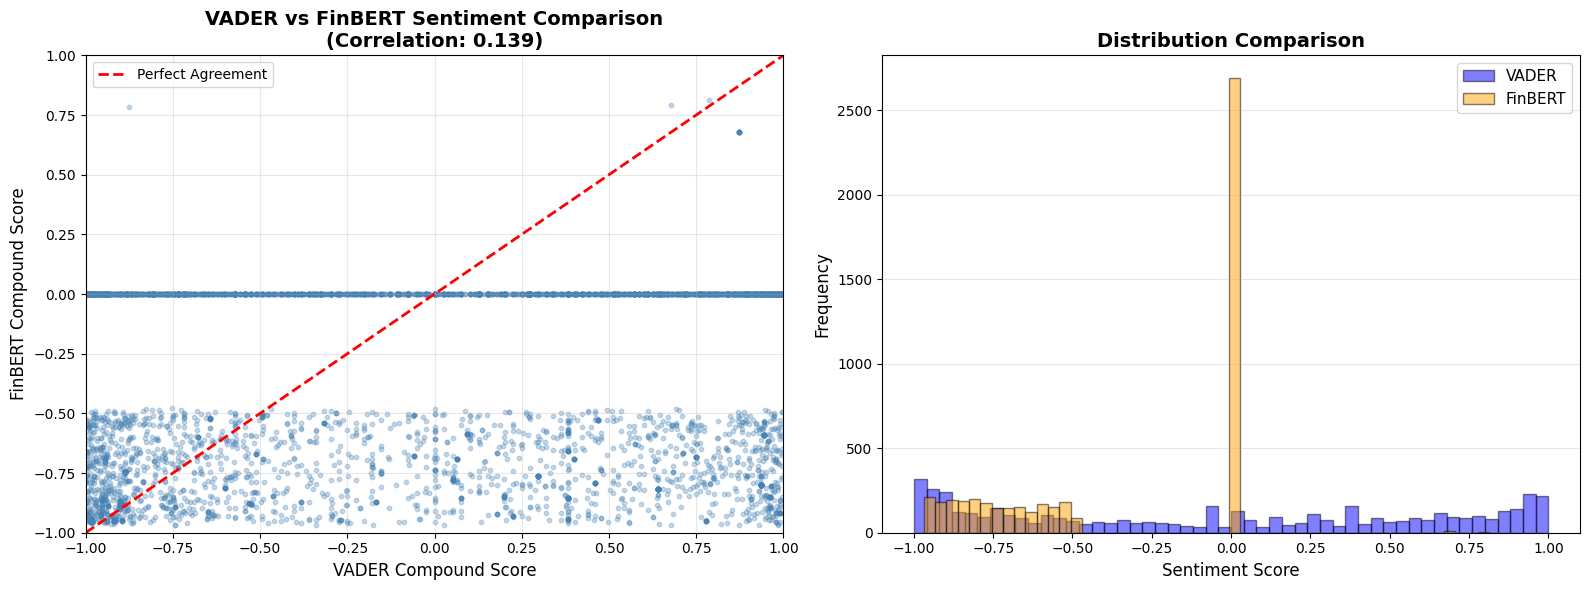


VALIDATION COMPLETE


In [59]:
# ─── USAGE ───
sample_with_finbert, correlation = validate_vader_with_finbert(df, sample_size=5000)

In [62]:
if sample_with_finbert is not None:
    sample_with_finbert.to_csv('data/vader_finbert_validation_sample.csv', index=False)
    print("\nSaved validation sample: vader_finbert_validation_sample.csv")


Saved validation sample: vader_finbert_validation_sample.csv


#### p-value test to verify sufficiency of sample size

In [75]:
# Statistical test
import scipy.stats as stats

r = 0.139
n = 5000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0


### RoBERT-a

In [63]:
from transformers import pipeline

def validate_vader_with_roberta(df, sample_size=5000):
    """
    Validate VADER against RoBERTa (Twitter-trained)
    Better domain match than FinBERT
    """
    
    print("=" * 70)
    print("VADER vs RoBERTa-Twitter VALIDATION")
    print("=" * 70)
    
    # Sample
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"\nSampled {len(sample_df):,} complaints")
    
    # Load RoBERTa
    print("\nLoading RoBERTa-Twitter model (CPU mode)...")
    
    try:
        roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1,  # CPU
            max_length=512,
            truncation=True
        )
        
        print("   RoBERTa loaded!")
        print("   Domain: Social media / subjective text")
        
    except Exception as e:
        print(f"   Error: {e}")
        return None, None
    
    # Process
    print(f"\nProcessing {len(sample_df):,} complaints...")
    
    roberta_scores = []
    label_counts = {'negative': 0, 'neutral': 0, 'positive': 0, 'error': 0}
    
    for text in tqdm(sample_df['narrative_clean'], desc="RoBERTa processing"):
        
        if pd.isna(text) or not text:
            roberta_scores.append(0)
            label_counts['error'] += 1
            continue
        
        try:
            result = roberta(text[:512])[0]
            
            label = result['label'].lower()
            score = result['score']
            
            # RoBERTa returns: negative, neutral, positive
            if label == 'positive':
                compound = score
                label_counts['positive'] += 1
            elif label == 'negative':
                compound = -score
                label_counts['negative'] += 1
            elif label == 'neutral':
                compound = 0.0
                label_counts['neutral'] += 1
            else:
                compound = 0.0
                label_counts['error'] += 1
            
            roberta_scores.append(compound)
            
        except Exception as e:
            roberta_scores.append(0)
            label_counts['error'] += 1
    
    print(f"\nRoBERTa Label Distribution:")
    for label, count in label_counts.items():
        pct = count / len(sample_df) * 100
        print(f"   {label.capitalize():8s}: {count:5,} ({pct:5.1f}%)")
    
    sample_df['roberta_compound'] = roberta_scores
    
    # Correlation
    print("\n" + "=" * 70)
    print("VADER vs RoBERTa COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'roberta_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong correlation! VADER validated.")
    elif correlation > 0.50:
        print(f"   Moderate correlation. VADER is reasonable.")
    else:
        print(f"   Weak correlation.")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['roberta_compound']).mean()
    print(f"   MAE: {mae:.3f}")
    
    # Directional agreement
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    roberta_pos = (sample_df['roberta_compound'] > 0).astype(int)
    agreement = (vader_pos == roberta_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['roberta_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound')
    ax1.set_ylabel('RoBERTa Compound')
    ax1.set_title(f'VADER vs RoBERTa\n(Correlation: {correlation:.3f})')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue')
    ax2.hist(sample_df['roberta_compound'], bins=50, alpha=0.5,
            label='RoBERTa', color='green')
    ax2.set_xlabel('Sentiment Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution Comparison')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_roberta_comparison.png', dpi=300)
    print("\nSaved: vader_roberta_comparison.png")
    plt.show()
    
    return sample_df, correlation

VADER vs RoBERTa-Twitter VALIDATION

Sampled 5,000 complaints

Loading RoBERTa-Twitter model (CPU mode)...


C:\Users\shubh\hw_FAI\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shubh\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|█| 201/201 [00:00<00:00, 1052.67it/s, Materializing param=roberta.

   RoBERTa loaded!
   Domain: Social media / subjective text

Processing 5,000 complaints...


RoBERTa processing: 100%|███████████████████████████████████████████████████████████| 5000/5000 [02:25<00:00, 34.29it/s]



RoBERTa Label Distribution:
   Negative: 3,870 ( 77.4%)
   Neutral : 1,099 ( 22.0%)
   Positive:    31 (  0.6%)
   Error   :     0 (  0.0%)

VADER vs RoBERTa COMPARISON

Correlation: 0.209
   Weak correlation.
   MAE: 0.702
   Directional agreement: 53.1%

Saved: vader_roberta_comparison.png


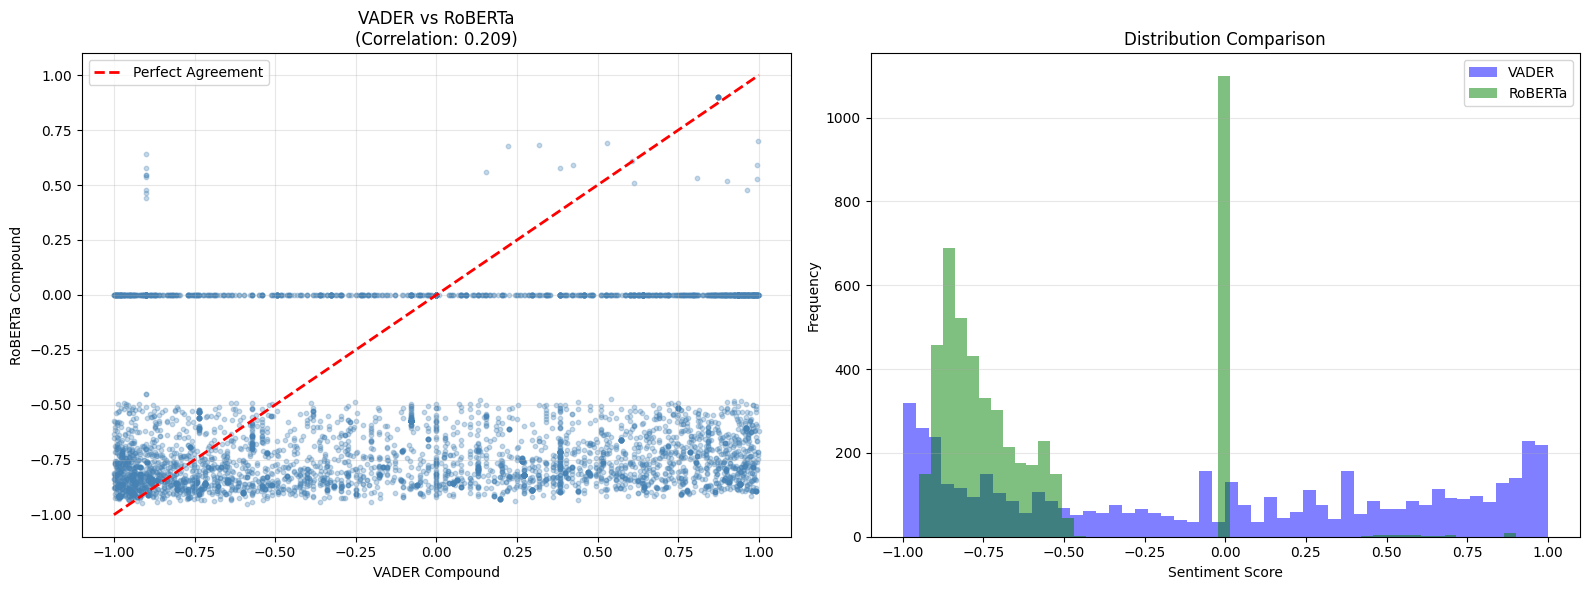

In [64]:
# ─── USAGE ───
sample_roberta, corr_roberta = validate_vader_with_roberta(df, sample_size=5000)

In [65]:
if sample_roberta is not None:
    sample_roberta.to_csv('data/vader_roberta_validation_sample.csv', index=False)
    print("\nSaved validation sample: vader_roberta_validation_sample.csv")


Saved validation sample: vader_roberta_validation_sample.csv


#### p-value test to verify sufficiency of sample size

In [76]:
# Statistical test
import scipy.stats as stats

r = 0.209
n = 5000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0


## Validating Modern Transformers - Sample Size 10k

In [5]:
df = pd.read_csv('data/complaints_with_nlp_features.csv',engine="python",
                 on_bad_lines="skip")
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17


### VADER vs FinBERT 10k

In [6]:
def validate_vader_with_finbert(df, sample_size=5000):
    """
    Validate VADER sentiment against FinBERT on a sample
    """
    
    print("=" * 70)
    print("FINBERT VALIDATION: VADER vs Modern Transformers")
    print("=" * 70)
    
    # Sample
    print(f"\nSampling {sample_size:,} complaints for validation...")
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"   Sampled {len(sample_df):,} complaints")
    
    # Load FinBERT
    print("\nLoading FinBERT model...")
    print("   Status: Downloading model weights (first time only)...")
    
    try:
        from transformers import pipeline
        import torch
        
        device = 0 if torch.cuda.is_available() else -1
        # device = -1
        
        print("   Status: Initializing model...")
        finbert = pipeline(
            "sentiment-analysis",
            model="ProsusAI/finbert",
            device=device,
            max_length=512,
            truncation=True
        )
        
        print("   FinBERT loaded successfully!")
        
        if device == 0:
            print("   Using GPU acceleration")
        else:
            print("   Using CPU (slower)")
        
    except Exception as e:
        print(f"\nError loading FinBERT: {e}")
        return None, None
    
    # Process with FinBERT using tqdm progress bar
    print(f"\nProcessing {len(sample_df):,} complaints with FinBERT...")
    
    if device == -1:  # CPU
        estimated_time = len(sample_df) * 0.2  # ~0.2 sec per complaint on CPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    else:  # GPU
        estimated_time = len(sample_df) * 0.05  # ~0.05 sec per complaint on GPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    
    finbert_scores = []
    
    start_time = time.time()
    
    # Use tqdm for progress bar
    for idx, text in tqdm(enumerate(sample_df['narrative_clean']), 
                          total=len(sample_df),
                          desc="Processing complaints",
                          unit="complaint",
                          ncols=100):
        
        if pd.isna(text) or not text:
            finbert_scores.append(0)
            continue
        
        try:
            result = finbert(text[:512])[0]
            
            if result['label'] == 'positive':
                score = result['score']
            elif result['label'] == 'negative':
                score = -result['score']
            else:
                score = 0
            
            finbert_scores.append(score)
            
        except Exception as e:
            finbert_scores.append(0)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n   Processing complete!")
    print(f"   Total time: {elapsed_time/60:.1f} minutes")
    print(f"   Speed: {len(sample_df)/elapsed_time:.1f} complaints/second")
    
    sample_df['finbert_compound'] = finbert_scores
    
    print("\n" + "=" * 70)
    print("VADER vs FinBERT COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'finbert_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation Analysis:")
    print(f"   Pearson correlation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong positive correlation!")
    elif correlation > 0.50:
        print(f"   Moderate correlation")
    else:
        print(f"   Weak correlation")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['finbert_compound']).mean()
    print(f"   Mean Absolute Error: {mae:.3f}")
    
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    finbert_pos = (sample_df['finbert_compound'] > 0).astype(int)
    agreement = (vader_pos == finbert_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    print("\nGenerating comparison visualizations...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['finbert_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound Score', fontsize=12)
    ax1.set_ylabel('FinBERT Compound Score', fontsize=12)
    ax1.set_title(f'VADER vs FinBERT Sentiment Comparison\n(Correlation: {correlation:.3f})',
                 fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xlim(-1, 1)
    ax1.set_ylim(-1, 1)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue', edgecolor='black')
    ax2.hist(sample_df['finbert_compound'], bins=50, alpha=0.5,
            label='FinBERT', color='orange', edgecolor='black')
    ax2.set_xlabel('Sentiment Score', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_finbert_comparison.png', dpi=300, bbox_inches='tight')
    print("   Saved: vader_finbert_comparison.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("VALIDATION COMPLETE")
    print("=" * 70)
    
    return sample_df, correlation

FINBERT VALIDATION: VADER vs Modern Transformers

Sampling 10,000 complaints for validation...
   Sampled 10,000 complaints

Loading FinBERT model...
   Status: Downloading model weights (first time only)...


C:\Users\shubh\hw_FAI\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Status: Initializing model...


Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 344.09it/s, Materializing param=classifier.weight]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   FinBERT loaded successfully!
   Using GPU acceleration

Processing 10,000 complaints with FinBERT...
   Estimated time: 8.3 minutes


Processing complaints: 100%|███████████████████████████| 10000/10000 [02:56<00:00, 56.69complaint/s]



   Processing complete!
   Total time: 2.9 minutes
   Speed: 56.7 complaints/second

VADER vs FinBERT COMPARISON

Correlation Analysis:
   Pearson correlation: 0.134
   Weak correlation
   Mean Absolute Error: 0.637
   Directional agreement: 52.7%

Generating comparison visualizations...
   Saved: vader_finbert_comparison.png


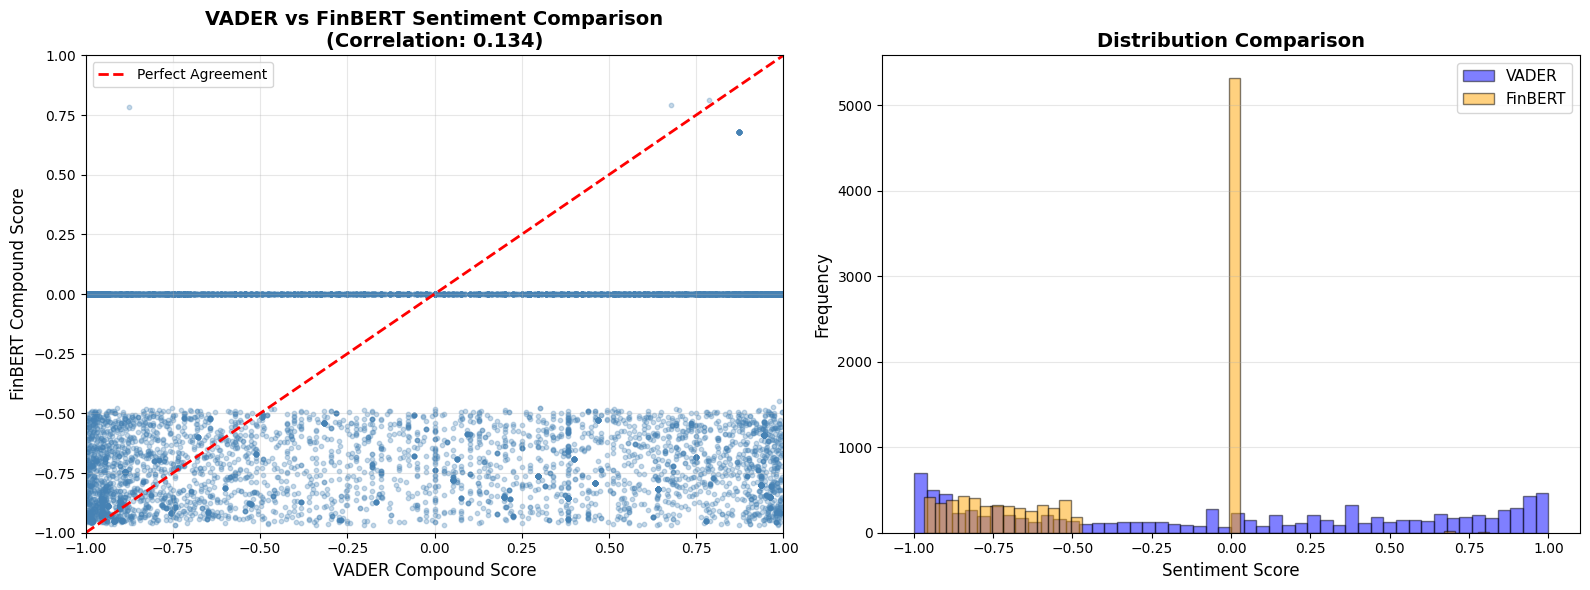


VALIDATION COMPLETE


In [7]:
sample_with_finbert, correlation = validate_vader_with_finbert(df, sample_size=10000)

In [8]:
if sample_with_finbert is not None:
    sample_with_finbert.to_csv('data/vader_finbert_validation_sample_10k.csv', index=False)
    print("\nSaved validation sample: vader_finbert_validation_sample_10k.csv")


Saved validation sample: vader_finbert_validation_sample_10k.csv


In [9]:
# Statistical test
import scipy.stats as stats

r = 0.134
n = 10000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0


### VADER vs RoBERT-a 10k

In [10]:
from transformers import pipeline

def validate_vader_with_roberta(df, sample_size=5000):
    """
    Validate VADER against RoBERTa (Twitter-trained)
    Better domain match than FinBERT
    """
    
    print("=" * 70)
    print("VADER vs RoBERTa-Twitter VALIDATION")
    print("=" * 70)
    
    # Sample
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"\nSampled {len(sample_df):,} complaints")
    
    # Load RoBERTa
    print("\nLoading RoBERTa-Twitter model (CPU mode)...")
    
    try:
        roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1,  # CPU
            max_length=512,
            truncation=True
        )
        
        print("   RoBERTa loaded!")
        print("   Domain: Social media / subjective text")
        
    except Exception as e:
        print(f"   Error: {e}")
        return None, None
    
    # Process
    print(f"\nProcessing {len(sample_df):,} complaints...")
    
    roberta_scores = []
    label_counts = {'negative': 0, 'neutral': 0, 'positive': 0, 'error': 0}
    
    for text in tqdm(sample_df['narrative_clean'], desc="RoBERTa processing"):
        
        if pd.isna(text) or not text:
            roberta_scores.append(0)
            label_counts['error'] += 1
            continue
        
        try:
            result = roberta(text[:512])[0]
            
            label = result['label'].lower()
            score = result['score']
            
            # RoBERTa returns: negative, neutral, positive
            if label == 'positive':
                compound = score
                label_counts['positive'] += 1
            elif label == 'negative':
                compound = -score
                label_counts['negative'] += 1
            elif label == 'neutral':
                compound = 0.0
                label_counts['neutral'] += 1
            else:
                compound = 0.0
                label_counts['error'] += 1
            
            roberta_scores.append(compound)
            
        except Exception as e:
            roberta_scores.append(0)
            label_counts['error'] += 1
    
    print(f"\nRoBERTa Label Distribution:")
    for label, count in label_counts.items():
        pct = count / len(sample_df) * 100
        print(f"   {label.capitalize():8s}: {count:5,} ({pct:5.1f}%)")
    
    sample_df['roberta_compound'] = roberta_scores
    
    # Correlation
    print("\n" + "=" * 70)
    print("VADER vs RoBERTa COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'roberta_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong correlation! VADER validated.")
    elif correlation > 0.50:
        print(f"   Moderate correlation. VADER is reasonable.")
    else:
        print(f"   Weak correlation.")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['roberta_compound']).mean()
    print(f"   MAE: {mae:.3f}")
    
    # Directional agreement
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    roberta_pos = (sample_df['roberta_compound'] > 0).astype(int)
    agreement = (vader_pos == roberta_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['roberta_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound')
    ax1.set_ylabel('RoBERTa Compound')
    ax1.set_title(f'VADER vs RoBERTa\n(Correlation: {correlation:.3f})')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue')
    ax2.hist(sample_df['roberta_compound'], bins=50, alpha=0.5,
            label='RoBERTa', color='green')
    ax2.set_xlabel('Sentiment Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution Comparison')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_roberta_comparison.png', dpi=300)
    print("\nSaved: vader_roberta_comparison.png")
    plt.show()
    
    return sample_df, correlation

VADER vs RoBERTa-Twitter VALIDATION

Sampled 10,000 complaints

Loading RoBERTa-Twitter model (CPU mode)...


Loading weights: 100%|█| 201/201 [00:00<00:00, 830.40it/s, Materializing param=roberta.encoder.layer.11.outp
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   RoBERTa loaded!
   Domain: Social media / subjective text

Processing 10,000 complaints...


RoBERTa processing: 100%|█████████████████████████████████████████████| 10000/10000 [10:50<00:00, 15.38it/s]



RoBERTa Label Distribution:
   Negative: 7,755 ( 77.5%)
   Neutral : 2,182 ( 21.8%)
   Positive:    63 (  0.6%)
   Error   :     0 (  0.0%)

VADER vs RoBERTa COMPARISON

Correlation: 0.207
   Weak correlation.
   MAE: 0.706
   Directional agreement: 52.7%

Saved: vader_roberta_comparison.png


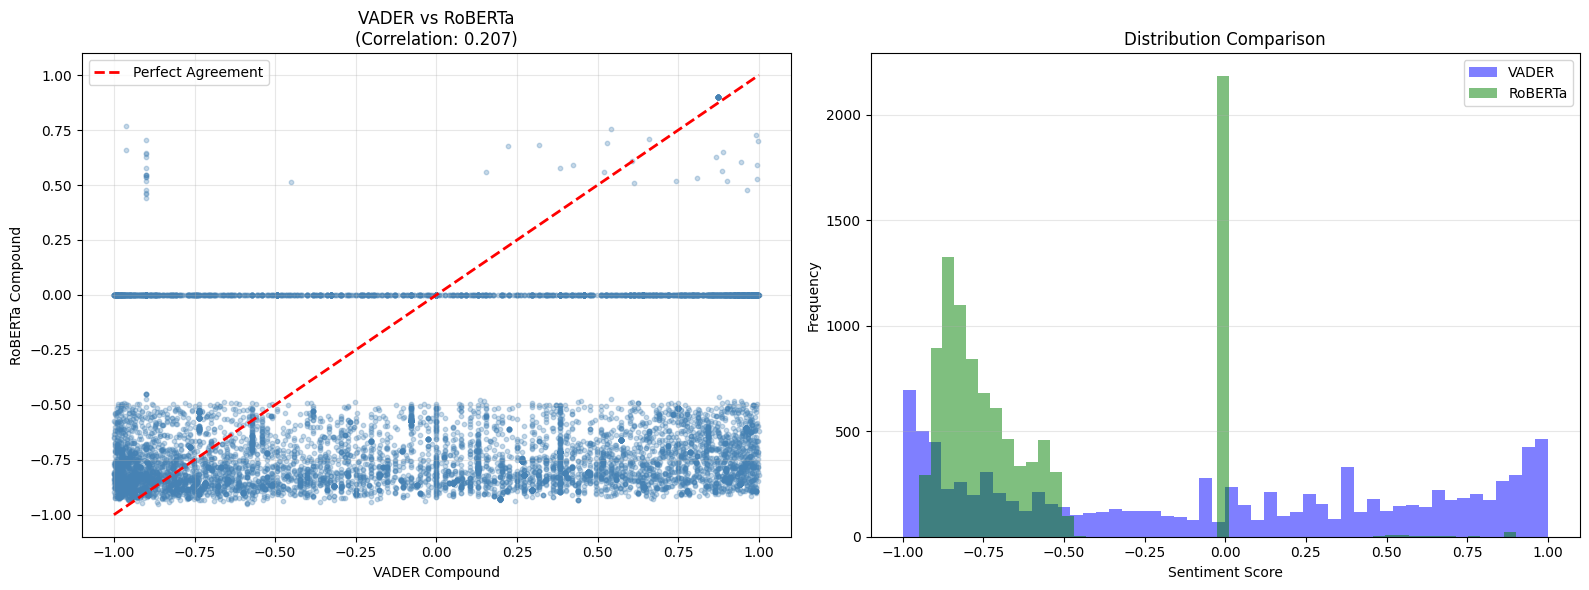

In [11]:
sample_roberta, corr_roberta = validate_vader_with_roberta(df, sample_size=10000)

In [12]:
if sample_roberta is not None:
    sample_roberta.to_csv('data/vader_roberta_validation_sample_10k.csv', index=False)
    print("\nSaved validation sample: vader_roberta_validation_sample_10k.csv")


Saved validation sample: vader_roberta_validation_sample_10k.csv


In [13]:
# Statistical test
import scipy.stats as stats

r = 0.207
n = 10000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0


## Validating Modern Transformers - Sample Size 50k

In [5]:
df = pd.read_csv('data/complaints_with_nlp_features.csv',engine="python",
                 on_bad_lines="skip")
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative_clean,narrative_no_stopwords,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count
0,01/20/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am writing to have the following information...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,NaN,Consent provided,Web,01/20/25,Closed with non-monetary relief,Yes,NaN,11588109,i am writing to have the following information...,writing following information removed credit f...,0.9430,0.037,0.794,0.169,0.0,0.4,0.0,662,119
1,07/03/24,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,I am a victim of identity theft. Please delete...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,32824,NaN,Consent provided,Web,07/03/24,Closed with non-monetary relief,Yes,NaN,9416677,i am a victim of identity theft. please delete...,victim identity theft please delete remove ite...,0.2732,0.100,0.760,0.139,0.0,0.0,0.0,370,68
2,09/14/25,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"My name is XXXX XXXX, and I am formally disput...",NaN,"SANTANDER HOLDINGS USA, INC.",PA,19143,NaN,Consent provided,Web,09/14/25,Closed with explanation,Yes,NaN,15930829,"my name is xxxx xxxx, and i am formally disput...",name xxxx xxxx formally disputing fraudulent a...,-0.9042,0.151,0.766,0.083,1.0,0.4,0.0,830,140
3,05/01/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Upon reviewing my credit report, I have identi...",Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,NaN,Consent provided,Web,05/01/25,Closed with non-monetary relief,Yes,NaN,13274568,"upon reviewing my credit report, i have identi...",upon reviewing credit report identified inaccu...,0.3818,0.000,0.867,0.133,0.0,0.0,0.0,127,18
4,12/08/25,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Everything is explained in my resolution packa...,Company believes it acted appropriately as aut...,Kubota North America Corporation,MS,391XX,NaN,Consent provided,Web,12/08/25,Closed with explanation,Yes,NaN,17837761,everything is explained in my resolution packa...,everything explained resolution package ive al...,0.3818,0.000,0.860,0.140,0.0,0.0,0.0,107,17


### VADER vs FinBERT 50k

In [8]:
def validate_vader_with_finbert(df, sample_size=5000):
    """
    Validate VADER sentiment against FinBERT on a sample
    """
    
    print("=" * 70)
    print("FINBERT VALIDATION: VADER vs Modern Transformers")
    print("=" * 70)
    
    # Sample
    print(f"\nSampling {sample_size:,} complaints for validation...")
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"   Sampled {len(sample_df):,} complaints")
    
    # Load FinBERT
    print("\nLoading FinBERT model...")
    print("   Status: Downloading model weights (first time only)...")
    
    try:
        from transformers import pipeline
        import torch
        
        device = 0 if torch.cuda.is_available() else -1
        # device = -1
        
        print("   Status: Initializing model...")
        finbert = pipeline(
            "sentiment-analysis",
            model="ProsusAI/finbert",
            device=device,
            max_length=512,
            truncation=True
        )
        
        print("   FinBERT loaded successfully!")
        
        if device == 0:
            print("   Using GPU acceleration")
        else:
            print("   Using CPU (slower)")
        
    except Exception as e:
        print(f"\nError loading FinBERT: {e}")
        return None, None
    
    # Process with FinBERT using tqdm progress bar
    print(f"\nProcessing {len(sample_df):,} complaints with FinBERT...")
    
    if device == -1:  # CPU
        estimated_time = len(sample_df) * 0.2  # ~0.2 sec per complaint on CPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    else:  # GPU
        estimated_time = len(sample_df) * 0.05  # ~0.05 sec per complaint on GPU
        print(f"   Estimated time: {estimated_time/60:.1f} minutes")
    
    finbert_scores = []
    
    start_time = time.time()
    
    # Use tqdm for progress bar
    for idx, text in tqdm(enumerate(sample_df['narrative_clean']), 
                          total=len(sample_df),
                          desc="Processing complaints",
                          unit="complaint",
                          ncols=100):
        
        if pd.isna(text) or not text:
            finbert_scores.append(0)
            continue
        
        try:
            result = finbert(text[:512])[0]
            
            if result['label'] == 'positive':
                score = result['score']
            elif result['label'] == 'negative':
                score = -result['score']
            else:
                score = 0
            
            finbert_scores.append(score)
            
        except Exception as e:
            finbert_scores.append(0)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n   Processing complete!")
    print(f"   Total time: {elapsed_time/60:.1f} minutes")
    print(f"   Speed: {len(sample_df)/elapsed_time:.1f} complaints/second")
    
    sample_df['finbert_compound'] = finbert_scores
    
    print("\n" + "=" * 70)
    print("VADER vs FinBERT COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'finbert_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation Analysis:")
    print(f"   Pearson correlation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong positive correlation!")
    elif correlation > 0.50:
        print(f"   Moderate correlation")
    else:
        print(f"   Weak correlation")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['finbert_compound']).mean()
    print(f"   Mean Absolute Error: {mae:.3f}")
    
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    finbert_pos = (sample_df['finbert_compound'] > 0).astype(int)
    agreement = (vader_pos == finbert_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    print("\nGenerating comparison visualizations...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['finbert_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound Score', fontsize=12)
    ax1.set_ylabel('FinBERT Compound Score', fontsize=12)
    ax1.set_title(f'VADER vs FinBERT Sentiment Comparison\n(Correlation: {correlation:.3f})',
                 fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xlim(-1, 1)
    ax1.set_ylim(-1, 1)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue', edgecolor='black')
    ax2.hist(sample_df['finbert_compound'], bins=50, alpha=0.5,
            label='FinBERT', color='orange', edgecolor='black')
    ax2.set_xlabel('Sentiment Score', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_finbert_comparison.png', dpi=300, bbox_inches='tight')
    print("   Saved: vader_finbert_comparison.png")
    plt.show()
    
    print("\n" + "=" * 70)
    print("VALIDATION COMPLETE")
    print("=" * 70)
    
    return sample_df, correlation

FINBERT VALIDATION: VADER vs Modern Transformers

Sampling 50,000 complaints for validation...


   Sampled 50,000 complaints

Loading FinBERT model...
   Status: Downloading model weights (first time only)...
   Status: Initializing model...


Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 340.57it/s, Materializing param=classifier.weight]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   FinBERT loaded successfully!
   Using GPU acceleration

Processing 50,000 complaints with FinBERT...
   Estimated time: 41.7 minutes


Processing complaints: 100%|███████████████████████████| 50000/50000 [15:29<00:00, 53.76complaint/s]



   Processing complete!
   Total time: 15.5 minutes
   Speed: 53.8 complaints/second

VADER vs FinBERT COMPARISON

Correlation Analysis:
   Pearson correlation: 0.142
   Weak correlation
   Mean Absolute Error: 0.637
   Directional agreement: 53.1%

Generating comparison visualizations...
   Saved: vader_finbert_comparison.png


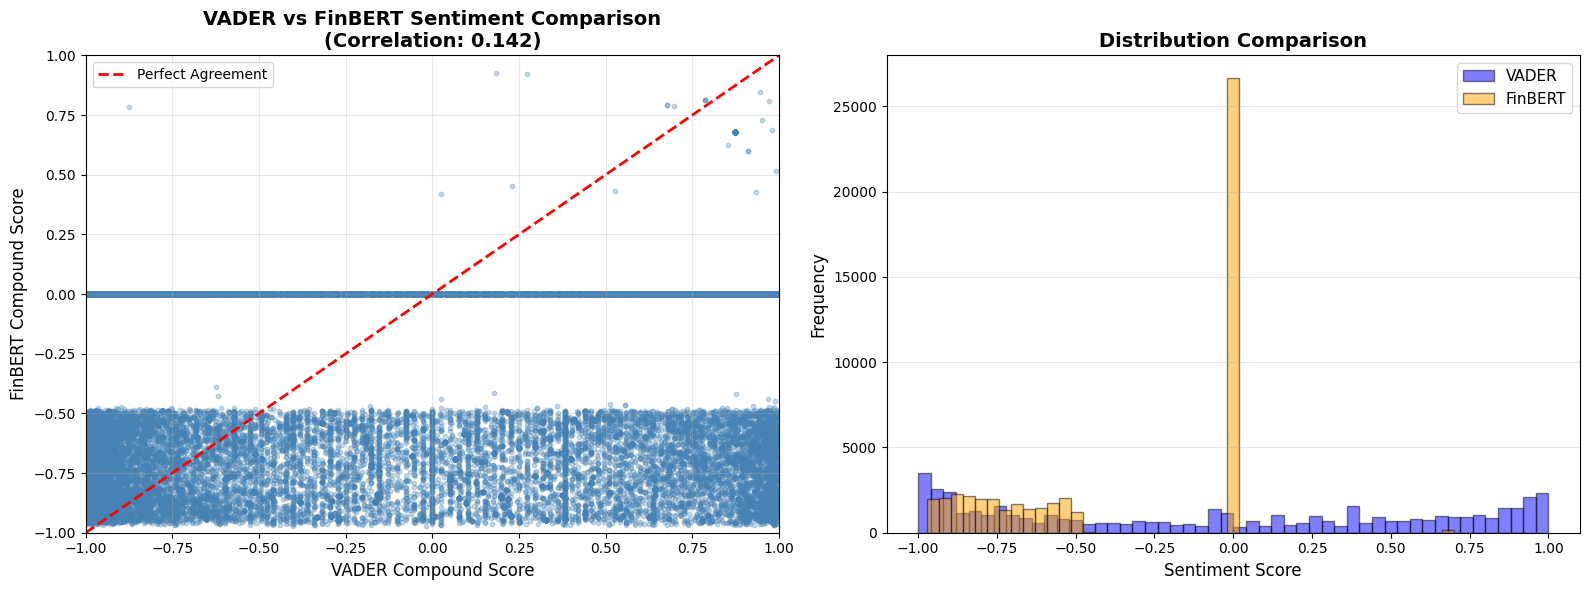


VALIDATION COMPLETE


In [9]:
sample_with_finbert, correlation = validate_vader_with_finbert(df, sample_size=50000)

In [10]:
if sample_with_finbert is not None:
    sample_with_finbert.to_csv('data/vader_finbert_validation_sample_50k.csv', index=False)
    print("\nSaved validation sample: vader_finbert_validation_sample_50k.csv")


Saved validation sample: vader_finbert_validation_sample_50k.csv


In [11]:
# Statistical test
import scipy.stats as stats

r = 0.142
n = 50000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0


### VADER vs RoBERT-a 50k

In [15]:
from transformers import pipeline

def validate_vader_with_roberta(df, sample_size=5000):
    """
    Validate VADER against RoBERTa (Twitter-trained)
    Better domain match than FinBERT
    """
    
    print("=" * 70)
    print("VADER vs RoBERTa-Twitter VALIDATION")
    print("=" * 70)
    
    # Sample
    sample_df = df[df['narrative_clean'].notna()].sample(
        n=min(sample_size, len(df)), 
        random_state=42
    ).copy()
    
    print(f"\nSampled {len(sample_df):,} complaints")
    
    # Load RoBERTa
    print("\nLoading RoBERTa-Twitter model ...")
    
    try:
        from transformers import pipeline
        import torch
        
        roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device = 0 if torch.cuda.is_available() else -1,
            max_length=512,
            truncation=True
        )
        
        print("   RoBERTa loaded!")
        print("   Domain: Social media / subjective text")
        
    except Exception as e:
        print(f"   Error: {e}")
        return None, None
    
    # Process
    print(f"\nProcessing {len(sample_df):,} complaints...")
    
    roberta_scores = []
    label_counts = {'negative': 0, 'neutral': 0, 'positive': 0, 'error': 0}
    
    for text in tqdm(sample_df['narrative_clean'], desc="RoBERTa processing"):
        
        if pd.isna(text) or not text:
            roberta_scores.append(0)
            label_counts['error'] += 1
            continue
        
        try:
            result = roberta(text[:512])[0]
            
            label = result['label'].lower()
            score = result['score']
            
            # RoBERTa returns: negative, neutral, positive
            if label == 'positive':
                compound = score
                label_counts['positive'] += 1
            elif label == 'negative':
                compound = -score
                label_counts['negative'] += 1
            elif label == 'neutral':
                compound = 0.0
                label_counts['neutral'] += 1
            else:
                compound = 0.0
                label_counts['error'] += 1
            
            roberta_scores.append(compound)
            
        except Exception as e:
            roberta_scores.append(0)
            label_counts['error'] += 1
    
    print(f"\nRoBERTa Label Distribution:")
    for label, count in label_counts.items():
        pct = count / len(sample_df) * 100
        print(f"   {label.capitalize():8s}: {count:5,} ({pct:5.1f}%)")
    
    sample_df['roberta_compound'] = roberta_scores
    
    # Correlation
    print("\n" + "=" * 70)
    print("VADER vs RoBERTa COMPARISON")
    print("=" * 70)
    
    correlation = sample_df[['sentiment_compound', 'roberta_compound']].corr().iloc[0, 1]
    
    print(f"\nCorrelation: {correlation:.3f}")
    
    if correlation > 0.75:
        print(f"   Strong correlation! VADER validated.")
    elif correlation > 0.50:
        print(f"   Moderate correlation. VADER is reasonable.")
    else:
        print(f"   Weak correlation.")
    
    mae = np.abs(sample_df['sentiment_compound'] - sample_df['roberta_compound']).mean()
    print(f"   MAE: {mae:.3f}")
    
    # Directional agreement
    vader_pos = (sample_df['sentiment_compound'] > 0).astype(int)
    roberta_pos = (sample_df['roberta_compound'] > 0).astype(int)
    agreement = (vader_pos == roberta_pos).mean()
    
    print(f"   Directional agreement: {agreement:.1%}")
    
    # Visualization
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    ax1.scatter(sample_df['sentiment_compound'], sample_df['roberta_compound'],
               alpha=0.3, s=10, c='steelblue')
    ax1.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Agreement')
    ax1.set_xlabel('VADER Compound')
    ax1.set_ylabel('RoBERTa Compound')
    ax1.set_title(f'VADER vs RoBERTa\n(Correlation: {correlation:.3f})')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(sample_df['sentiment_compound'], bins=50, alpha=0.5, 
            label='VADER', color='blue')
    ax2.hist(sample_df['roberta_compound'], bins=50, alpha=0.5,
            label='RoBERTa', color='green')
    ax2.set_xlabel('Sentiment Score')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution Comparison')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vader_roberta_comparison.png', dpi=300)
    print("\nSaved: vader_roberta_comparison.png")
    plt.show()
    
    return sample_df, correlation

VADER vs RoBERTa-Twitter VALIDATION

Sampled 50,000 complaints

Loading RoBERTa-Twitter model ...


Loading weights: 100%|█| 201/201 [00:00<00:00, 370.97it/s, Materializing param=roberta.encoder.layer.11.output.dense.we
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   RoBERTa loaded!
   Domain: Social media / subjective text

Processing 50,000 complaints...


RoBERTa processing: 100%|████████████████████████████████████████████████████████| 50000/50000 [12:10<00:00, 68.41it/s]



RoBERTa Label Distribution:
   Negative: 38,702 ( 77.4%)
   Neutral : 10,992 ( 22.0%)
   Positive:   306 (  0.6%)
   Error   :     0 (  0.0%)

VADER vs RoBERTa COMPARISON

Correlation: 0.190
   Weak correlation.
   MAE: 0.709
   Directional agreement: 53.1%

Saved: vader_roberta_comparison.png


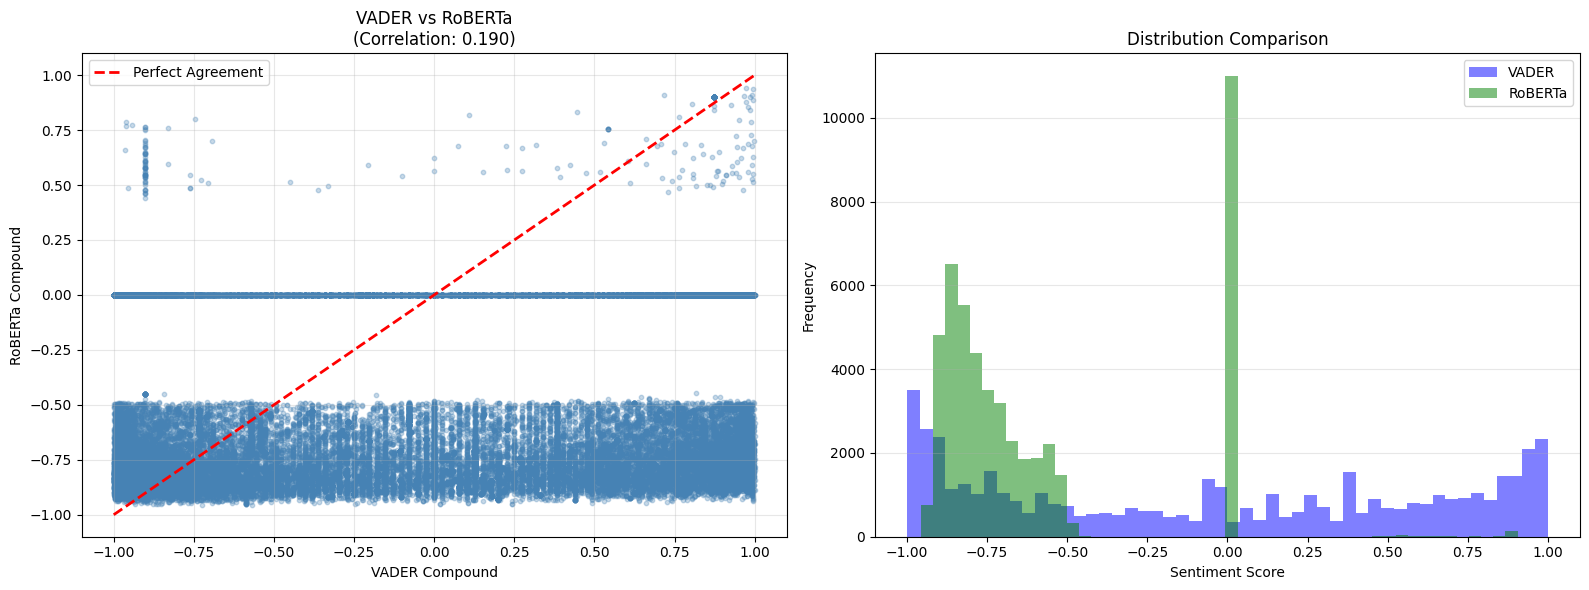

In [16]:
sample_roberta, corr_roberta = validate_vader_with_roberta(df, sample_size=50000)

In [17]:
if sample_roberta is not None:
    sample_roberta.to_csv('data/vader_roberta_validation_sample_50k.csv', index=False)
    print("\nSaved validation sample: vader_roberta_validation_sample_50k.csv")


Saved validation sample: vader_roberta_validation_sample_50k.csv


In [18]:
# Statistical test
import scipy.stats as stats

r = 0.190
n = 50000

# t-statistic
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)

# p-value (two-tailed)
p_value = 2 * (1 - stats.t.cdf(abs(t), n-2))
print(p_value)

0.0
